In [23]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv") 

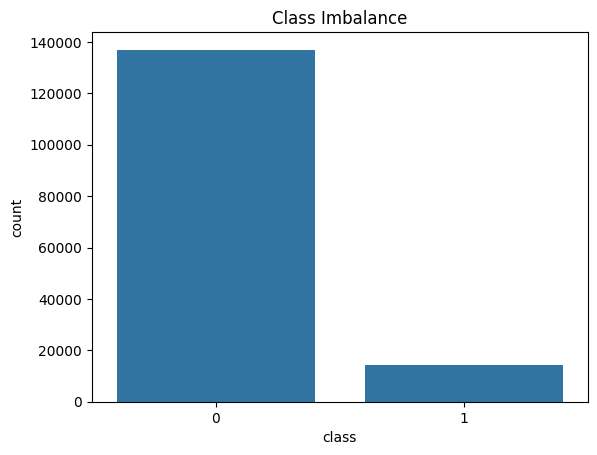

<Axes: xlabel='class', ylabel='purchase_value'>

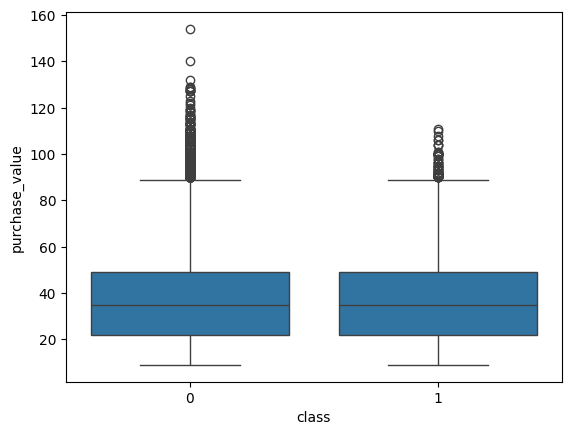

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(x='class', data=fraud_df)
plt.title('Class Imbalance')
plt.show()

# Bivariate example
sns.boxplot(x='class', y='purchase_value', data=fraud_df)

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------------
# LOAD DATA
# ------------------------
fraud_data = pd.read_csv("../data/processed/cleaned_fraud_data.csv")

# ------------------------
# SPLIT FEATURES / TARGET
# ------------------------
X = fraud_data.drop('class', axis=1)
y = fraud_data['class']

# ------------------------
# TRAIN TEST SPLIT
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120889, 10)
Test shape: (30223, 10)


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# LOAD
fraud_data = pd.read_csv("../data/processed/cleaned_fraud_data.csv")

# FEATURE ENGINEERING
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

fraud_data['time_diff'] = (
    fraud_data['purchase_time'] - fraud_data['signup_time']
).dt.total_seconds()

fraud_data = fraud_data.drop(['signup_time', 'purchase_time'], axis=1)

# SPLIT
X = fraud_data.drop('class', axis=1)
y = fraud_data['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ready for model training")

Ready for model training


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# LOAD
fraud_data = pd.read_csv("../data/processed/cleaned_fraud_data.csv")

# FEATURE ENGINEERING
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

fraud_data['time_diff'] = (
    fraud_data['purchase_time'] - fraud_data['signup_time']
).dt.total_seconds()

fraud_data = fraud_data.drop(['signup_time', 'purchase_time'], axis=1)

# SPLIT
X = fraud_data.drop(columns=[
    'user_id',
    'device_id'
], errors='ignore')
y = fraud_data['class']
#
X = pd.get_dummies(X, drop_first=True)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# MODEL
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# PREDICT
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# EVALUATE
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.95      0.73      0.82     27393
           1       0.20      0.65      0.30      2830

    accuracy                           0.72     30223
   macro avg       0.58      0.69      0.56     30223
weighted avg       0.88      0.72      0.78     30223

ROC-AUC: 0.7116560948549054


In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("../data/raw/Fraud_Data.csv")

# =========================
# 2. BASIC CLEANING
# =========================
df = df.drop_duplicates()

# Convert datetime
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# Feature engineering (IMPORTANT for fraud)
df['time_diff'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds()

# Drop raw datetime columns
df = df.drop(['signup_time', 'purchase_time'], axis=1)

# =========================
# 3. DROP HIGH-RISK LEAKAGE COLUMNS
# =========================
# (IDs and identifiers that cause memorization)
leakage_cols = [
    'user_id',
    'device_id',
    'ip_address'
]

df = df.drop(columns=leakage_cols, errors='ignore')

# =========================
# 4. SEPARATE FEATURES & TARGET
# =========================
X = df.drop('class', axis=1)
y = df['class']

# =========================
# 5. ENCODE CATEGORICAL VARIABLES SAFELY
# =========================
cat_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# =========================
# 6. STRATIFIED CROSS VALIDATION
# =========================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================
# 7. MODEL
# =========================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# =========================
# 8. CROSS VALIDATION (REALISTIC)
# =========================
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=skf,
    scoring='average_precision'
)

print("AUC-PR Scores:", scores)
print("Mean AUC-PR:", scores.mean())

# =========================
# 9. FINAL TRAIN/TEST SPLIT (FOR REPORTING)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train final model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# =========================
# 10. EVALUATION
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

# =========================
# 11. DUPLICATE CHECK (DIAGNOSTIC)
# =========================
print("\nDuplicate rows:", df.duplicated().sum())

AUC-PR Scores: [0.60121622 0.5969416  0.61227117 0.61632995 0.60092894]
Mean AUC-PR: 0.6055375752907793

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     27393
           1       0.92      0.53      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.94      0.76      0.82     30223
weighted avg       0.95      0.95      0.95     30223


ROC-AUC: 0.7577486136550065

Duplicate rows: 6852
